  Numeric Model — Lung Disease Classification
  Device  : cuda
  Dataset : /kaggle/input/datasets/souptik22fiitbs/numerical-data/blood_respiratory_dataset_plus_1900_outliers_8900.csv

  Classes (5): ['Bacterial', 'COVID-19', 'Healthy', 'Tuberculosis', 'Viral Pneumonia']
  Train: 6229  |  Val: 890  |  Test: 1781

  Model architecture:
NumericModel(
  (mlp_entry): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
  )
  (res_block1): ResidualBlock(
    (fc1): Linear(in_features=64, out_features=128, bias=True)
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (relu): ReLU(

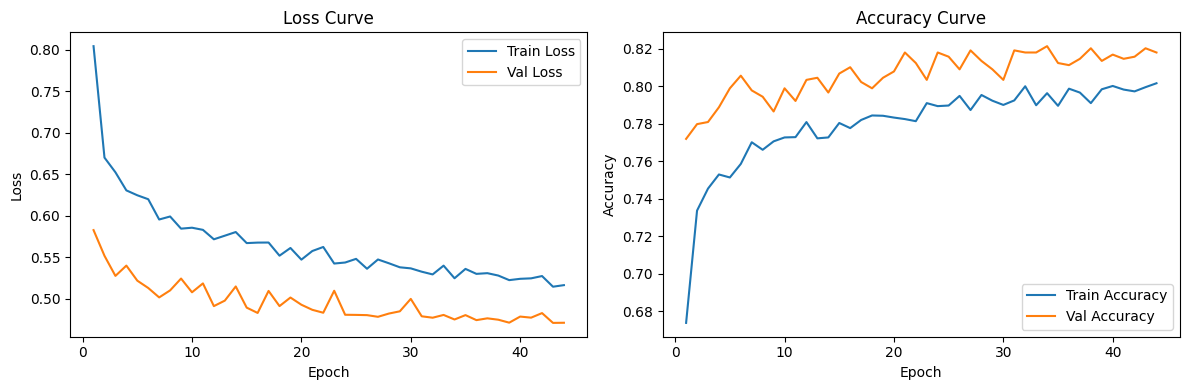

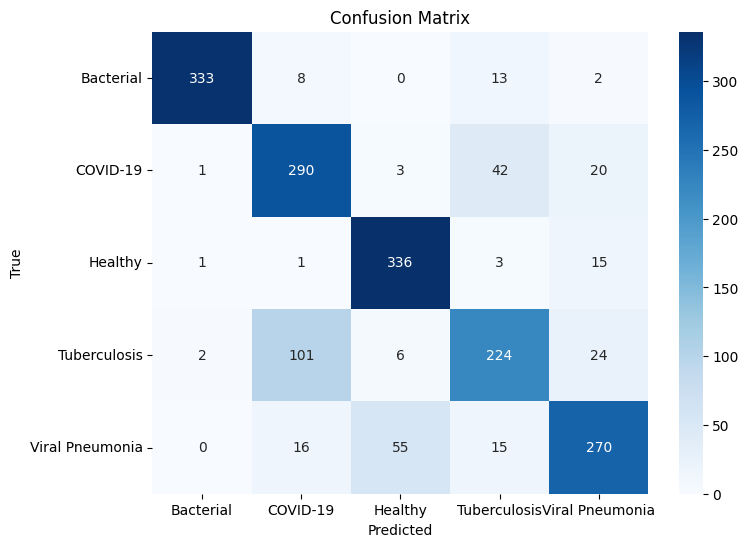


===== OVERALL METRICS =====
Accuracy     : 0.8158
Precision    : 0.8190
Recall       : 0.8158
F1 Score     : 0.8144
Specificity  : 0.9540


In [5]:
"""
Numeric Model Implementation
==============================
Based on the multimodal lung disease classification paper architecture.

Numeric branch:
  Input (blood markers) → MLP with ReLU → Residual Connection → Feature vector

Dataset: lung_blood_markers.csv
Features: WBC, NEUT%, LYMP%, NLR, CRP, PCT
Labels:   Healthy, Viral Pneumonia, Bacterial Pneumonia,
          COVID-19 Viral Pneumonia, Tuberculosis
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. DATASET
# ─────────────────────────────────────────────

class LungBloodMarkersDataset(Dataset):
    """
    PyTorch Dataset wrapping the blood-marker CSV.
    Features: WBC, NEUT%, LYMP%, NLR, CRP, PCT  (6 numeric biomarkers)
    Labels  : 5 classes (Healthy, Viral, Bacterial, COVID-19, Tuberculosis)
    """

    FEATURE_COLS = [
        "WBC (x10^9/L)", "NEUT%", "LYMP%",
        "NLR", "CRP (mg/L)", "PCT (ng/mL)",
    ]
    LABEL_COL = "Diagnosis_Label"

    def __init__(self, features: np.ndarray, labels: np.ndarray):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def load_and_preprocess(csv_path: str, test_size: float = 0.2,
                        val_size: float = 0.1, random_state: int = 42):
    """
    Load CSV, encode labels, standardise features, split into
    train / val / test sets.
    Returns: train_ds, val_ds, test_ds, scaler, label_encoder
    """
    df = pd.read_csv(csv_path)

    # Encode string labels → integer indices
    le = LabelEncoder()
    y_all = le.fit_transform(df[LungBloodMarkersDataset.LABEL_COL])
    X_all = df[LungBloodMarkersDataset.FEATURE_COLS].values.astype(np.float32)

    # Train / temp split, then temp → val / test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all, test_size=test_size + val_size,
        random_state=random_state, stratify=y_all
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=test_size / (test_size + val_size),
        random_state=random_state, stratify=y_temp
    )

    # Standardise (fit on training set only)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    train_ds = LungBloodMarkersDataset(X_train, y_train)
    val_ds   = LungBloodMarkersDataset(X_val,   y_val)
    test_ds  = LungBloodMarkersDataset(X_test,  y_test)

    return train_ds, val_ds, test_ds, scaler, le


# ─────────────────────────────────────────────
# 2. MODEL — MLP with ReLU + Residual Connection
# ─────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """
    Single residual block as described in the Numeric Model branch:
      x → Linear → BN → ReLU → Linear → BN → (+x) → ReLU

    A 1×1 (linear) projection is applied when in_dim ≠ out_dim
    so the skip connection dimensions always match.
    """

    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.3):
        super().__init__()
        self.fc1      = nn.Linear(in_dim,  out_dim)
        self.bn1      = nn.BatchNorm1d(out_dim)
        self.fc2      = nn.Linear(out_dim, out_dim)
        self.bn2      = nn.BatchNorm1d(out_dim)
        self.dropout  = nn.Dropout(dropout)
        self.relu     = nn.ReLU(inplace=True)

        # Projection shortcut when dimensions differ
        self.shortcut = (
            nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim))
            if in_dim != out_dim else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.bn2(self.fc2(out))

        out = self.relu(out + identity)   # Residual Connection
        return out


class NumericModel(nn.Module):
    """
    Numeric Model as depicted in the paper:

        Input (6 blood markers)
            ↓
        MLP with ReLU   ← Linear(6 → 64) + BN + ReLU
            ↓
        Residual Block  ← Linear(64 → 128) + BN + ReLU + skip
            ↓
        Residual Block  ← Linear(128 → 128) + BN + ReLU + skip
            ↓
        Feature vector  (128-d) ← would be fed to Feature Fusion in full model
            ↓
        Classifier head ← Linear(128 → num_classes)

    The 128-d output before the classifier head is the feature
    representation that maps to the "Feature Fusion" stage in the
    full multimodal architecture.
    """

    def __init__(self, in_dim: int = 6, hidden_dim: int = 64,
                 feature_dim: int = 128, num_classes: int = 5,
                 dropout: float = 0.3):
        super().__init__()

        # ── MLP with ReLU (entry projection) ──────────────────────────
        self.mlp_entry = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # ── Residual Connection blocks ─────────────────────────────────
        self.res_block1 = ResidualBlock(hidden_dim,  feature_dim, dropout)
        self.res_block2 = ResidualBlock(feature_dim, feature_dim, dropout)

        # ── Classifier head (stand-alone; omitted in full fusion model) ─
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x: torch.Tensor, return_features: bool = False):
        """
        Args:
            x               : (B, 6) normalised blood-marker tensor
            return_features : if True, return (logits, features) —
                              useful when plugging into Feature Fusion
        Returns:
            logits          : (B, num_classes)
            features (opt.) : (B, feature_dim) — the 128-d fusion vector
        """
        out = self.mlp_entry(x)       # (B, 64)
        out = self.res_block1(out)    # (B, 128)
        out = self.res_block2(out)    # (B, 128)

        features = out                # 128-d feature vector for fusion
        logits   = self.classifier(features)

        if return_features:
            return logits, features
        return logits


# ─────────────────────────────────────────────
# 3. TRAINING UTILITIES
# ─────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        logits     = model(X_batch)
        loss       = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        preds   = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


# ─────────────────────────────────────────────
# 4. PLOTTING
# ─────────────────────────────────────────────

def plot_training_curves(history: dict):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curve")
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Accuracy")
    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy")

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()

# ─────────────────────────────────────────────
# 5. MAIN
# ─────────────────────────────────────────────

def main():
    # ── Config ────────────────────────────────────────────────────────
    CSV_PATH    = "/kaggle/input/datasets/souptik22fiitbs/numerical-data/blood_respiratory_dataset_plus_1900_outliers_8900.csv"
    BATCH_SIZE  = 64
    LR          = 1e-3
    EPOCHS      = 60
    WEIGHT_DECAY= 1e-4
    PATIENCE    = 10          # early-stopping patience
    DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("=" * 60)
    print("  Numeric Model — Lung Disease Classification")
    print("=" * 60)
    print(f"  Device  : {DEVICE}")
    print(f"  Dataset : {CSV_PATH}")
    print()

    # ── Data ──────────────────────────────────────────────────────────
    train_ds, val_ds, test_ds, scaler, le = load_and_preprocess(CSV_PATH)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    class_names = list(le.classes_)
    num_classes  = len(class_names)
    print(f"  Classes ({num_classes}): {class_names}")
    print(f"  Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")
    print()

    # ── Model ─────────────────────────────────────────────────────────
    model = NumericModel(
        in_dim      = 6,
        hidden_dim  = 64,
        feature_dim = 128,
        num_classes = num_classes,
        dropout     = 0.3,
    ).to(DEVICE)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model architecture:\n{model}")
    print(f"\n  Trainable parameters: {total_params:,}\n")

    # ── Optimiser & loss ──────────────────────────────────────────────
    # Class-weighted CE to handle any residual imbalance
    class_counts  = np.bincount([int(s[1]) for s in train_ds])
    class_weights = torch.tensor(
        1.0 / class_counts, dtype=torch.float32
    ).to(DEVICE)
    class_weights = class_weights / class_weights.sum() * num_classes

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                                   weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-5
    )

    # ── Training loop ─────────────────────────────────────────────────
    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    best_val_acc   = 0.0
    patience_count = 0
    best_state     = None

    print(f"  {'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  "
          f"{'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}")
    print("  " + "-" * 60)

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                          optimizer, criterion, DEVICE)
        va_loss, va_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        cur_lr = scheduler.get_last_lr()[0]
        print(f"  {epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  "
              f"{va_loss:>8.4f}  {va_acc:>7.4f}  {cur_lr:>8.6f}")

        # Early stopping & best-model checkpoint
        if va_acc > best_val_acc:
            best_val_acc   = va_acc
            best_state     = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"\n  Early stopping at epoch {epoch} "
                      f"(best val acc: {best_val_acc:.4f})")
                break

    # ── Restore best weights ───────────────────────────────────────────
    model.load_state_dict(best_state)

    # ── Test evaluation ───────────────────────────────────────────────
    te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)
    y_pred, y_true  = predict(model, test_loader, DEVICE)

    print()
    print("=" * 60)
    print(f"  Test Loss : {te_loss:.4f}")
    print(f"  Test Acc  : {te_acc:.4f}  ({te_acc*100:.2f}%)")
    print("=" * 60)
    print()
    print("  Per-class metrics:")
    print(classification_report(y_true, y_pred,
                                 target_names=class_names, digits=4))

    # ── Demo: feature extraction for fusion ───────────────────────────
    print("  Feature extraction demo (for Feature Fusion stage):")
    sample_X = next(iter(test_loader))[0][:4].to(DEVICE)
    with torch.no_grad():
        logits, features = model(sample_X, return_features=True)
    print(f"    Input  shape : {sample_X.shape}")
    print(f"    Feature shape: {features.shape}  ← 128-d vector fed to Fusion")
    print(f"    Logits  shape: {logits.shape}")

    # ── Save artefacts ────────────────────────────────────────────────
    plot_training_curves(history)

    plot_confusion_matrix(
    y_true,
    y_pred,
    class_names
    )

    # Model checkpoint
    from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
    )

    
    # =========================
    # OVERALL METRICS
    # =========================
    
    accuracy  = accuracy_score(y_true, y_pred)
    
    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )
    
    # =========================
    # SPECIFICITY
    # =========================
    
    cm = confusion_matrix(y_true, y_pred)
    
    specificities = []
    
    for i in range(len(cm)):
    
        TP = cm[i, i]
    
        FN = np.sum(cm[i, :]) - TP
    
        FP = np.sum(cm[:, i]) - TP
    
        TN = np.sum(cm) - (TP + FN + FP)
    
        specificity = TN / (TN + FP)
    
        specificities.append(specificity)
    
    overall_specificity = np.mean(specificities)
    
    # =========================
    # PRINT RESULTS
    # =========================
    
    print("\n===== OVERALL METRICS =====")
    
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Specificity  : {overall_specificity:.4f}")
    

if __name__ == "__main__":
    main()